# Portefeuille Core-Satellite — Notebook Principal

| Étape | Module | Rôle |
|-------|--------|------|
| 1 | `core_pipeline` | Sélection des 3 ETF Core (Equity Europe / Rates / Credit) |
| 2 | `efficient_frontier_core` | Comparaison 5 stratégies d'allocation Core |
| 3 | `satellite_pipeline` | Shortlist 19 fonds, filtrage 4 niveaux, 3 blocs |
| 4 | `fond_construction` | Construction portefeuille, backtest OOS |
| 6 | `plots_report` | Graphiques complets |


**IS :** 01/01/2019 → 31/12/2020 — **OOS :** 01/01/2021 → 31/12/2025  
**Core :** `univers_core_etf_eur_daily_wide.xlsx` — **Satellite :** `STRAT1/2/3_info+price.xlsx`

In [1]:
import os, sys
from pathlib import Path

candidates = [
    Path.cwd(),
    Path(r'C:\Users\Marius\PycharmProjects\Core_Satellite_Quant'),
    Path('/Users/naz/Desktop/Core_Satellite_Quant'),
    Path('/workspaces/Core_Satellite_Quant'),
]
project_root = next((p for p in candidates if (p / 'src').exists()), Path.cwd())
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
(project_root / 'outputs' / 'figures').mkdir(parents=True, exist_ok=True)
print(f'Racine du projet : {Path.cwd()}')

Racine du projet : C:\Users\Marius\PycharmProjects\Core_Satellite_Quant


---
## Étape 1 — Sélection des ETF Core

Fichier : `univers_core_etf_eur_daily_wide.xlsx` — filtre exposition Equity = **Europe**  
Backtest rolling Max Sharpe : IS 2019-2020, OOS 2021-2025

In [2]:
from src.core_pipeline import main as core_main
core_main()

  PIPELINE CORE v5 – Format wide unifié
  Fichier : univers_core_etf_eur_daily_wide_VF.xlsx
  IS (sélection + calib) : 2019-01-01 → 2020-12-31
  OOS (validation)       : 2021-01-01 → 2025-12-31
  Equity weight floor    : 30%

[1/6] Lecture et filtrage des données...
  Lecture Equity...
    -> 12 ETFs | 2015-01-01 à 2026-02-27
    Filtre exposition (Europe) : 1 retenus, 11 exclus
    Filtrés : 1 retenus (excl. date 0, freq 0, frais 0)
  Lecture Rates...
    -> 12 ETFs | 2015-01-01 à 2026-02-27
    Filtrés : 8 retenus (excl. date 2, freq 0, frais 0)
  Lecture Credit...
    -> 12 ETFs | 2015-01-01 à 2026-02-27
    Filtrés : 7 retenus (excl. date 5, freq 0, frais 0)

[2/6] Sélection pick_best (1 ETF / thème)...
  Fenêtre de scoring : 2019-01-01 → 2020-12-31
  -> Equity : EUNK GY Equity
  -> Rates  : EUN9 GY Equity
  -> Credit : IEAA LN Equity

[3/6] Export sélection Core...
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\Core_finaux.csv
  -> C:\Users\Marius\PycharmProject

In [3]:
core_df = pd.read_csv("outputs/Core_finaux.csv")
print("✅ 3 ETF Core sélectionnés :")
display(core_df.style.hide(axis="index"))

✅ 3 ETF Core sélectionnés :


Ticker,Theme
EUNK GY Equity,Equity
EUN9 GY Equity,Rates
IEAA LN Equity,Credit


---
## Étape 2 — Comparaison des stratégies d'allocation Core

5 stratégies comparées : Max Sharpe IS, Min Variance IS, Equal Weight, Risk Parity, **Max Sharpe Rolling** (retenue).

In [27]:
from src.efficient_frontier_core import main as frontier_main
strategies, comp_df = frontier_main()

  COMPARAISON DES STRATÉGIES CORE (Markowitz daily)
  IS   : 2019-01-01 → 2020-12-31
  OOS  : 2021-01-01 → 2025-12-31

[1] Chargement des log-rendements journaliers des 3 ETF...
  ETFs : ['EUNK GY Equity', 'EUN9 GY Equity', 'IEAA LN Equity']
  Période : 2017-09-26 → 2026-02-27
  IS  : 523 obs | OOS : 1304 obs

[2] Simulation de la frontière (IS)...

[3] Optimisation des 4 stratégies statiques sur IS...
  Max Sharpe              w=[5.3%, 50.0%, 44.7%]  IS Sharpe=0.88  OOS Sharpe=-0.16
  Min Variance            w=[5.0%, 50.0%, 45.0%]  IS Sharpe=0.88  OOS Sharpe=-0.17
  Equal Weight            w=[33.3%, 33.3%, 33.3%]  IS Sharpe=0.67  OOS Sharpe=0.48
  Risk Parity             w=[9.2%, 60.4%, 30.4%]  IS Sharpe=0.91  OOS Sharpe=-0.12

[4] Backtest rolling Max Sharpe (252j lookback, 63j rebal, equity floor 30%)...
  Max Sharpe Rolling      (rolling)  IS Sharpe=0.85  OOS Sharpe=0.48

  TABLEAU COMPARATIF

Stratégie                    IS Ret   IS Vol   IS Sh  OOS Ret  OOS Vol  OOS Sh   OOS MDD


In [5]:
cols_is  = ['IS_ret_ann','IS_vol_ann','IS_sharpe']
cols_oos = ['OOS_ret_ann','OOS_vol_ann','OOS_sharpe','OOS_mdd']
fmt_pct  = {c: '{:.1%}' for c in cols_is + cols_oos if 'sharpe' not in c}
fmt_num  = {c: '{:.2f}' for c in cols_is + cols_oos if 'sharpe' in c}

print('=== IS (Calibration 2019-2020) ===')
display(comp_df[cols_is].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['IS_ret_ann','IS_sharpe'], color='lightgreen')
        .highlight_min(subset=['IS_vol_ann'], color='lightblue'))

print('\n=== OOS (Backtest 2021-2025) ===')
display(comp_df[cols_oos].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['OOS_ret_ann','OOS_sharpe'], color='lightgreen')
        .highlight_min(subset=['OOS_vol_ann','OOS_mdd'], color='lightblue'))

=== IS (Calibration 2019-2020) ===


,IS_ret_ann,IS_vol_ann,IS_sharpe
strategie,,,
Max Sharpe,3.9%,4.5%,0.88
Min Variance,3.9%,4.5%,0.88
Equal Weight,5.8%,8.7%,0.67
Risk Parity,4.1%,4.5%,0.91
Max Sharpe Rolling,7.3%,8.6%,0.85



=== OOS (Backtest 2021-2025) ===


,OOS_ret_ann,OOS_vol_ann,OOS_sharpe,OOS_mdd
strategie,,,,
Max Sharpe,-0.7%,4.5%,-0.16,-16.4%
Min Variance,-0.8%,4.5%,-0.17,-16.4%
Equal Weight,2.8%,5.9%,0.48,-15.8%
Risk Parity,-0.5%,4.6%,-0.12,-16.0%
Max Sharpe Rolling,3.4%,7.1%,0.48,-17.0%


Frontière efficiente IS


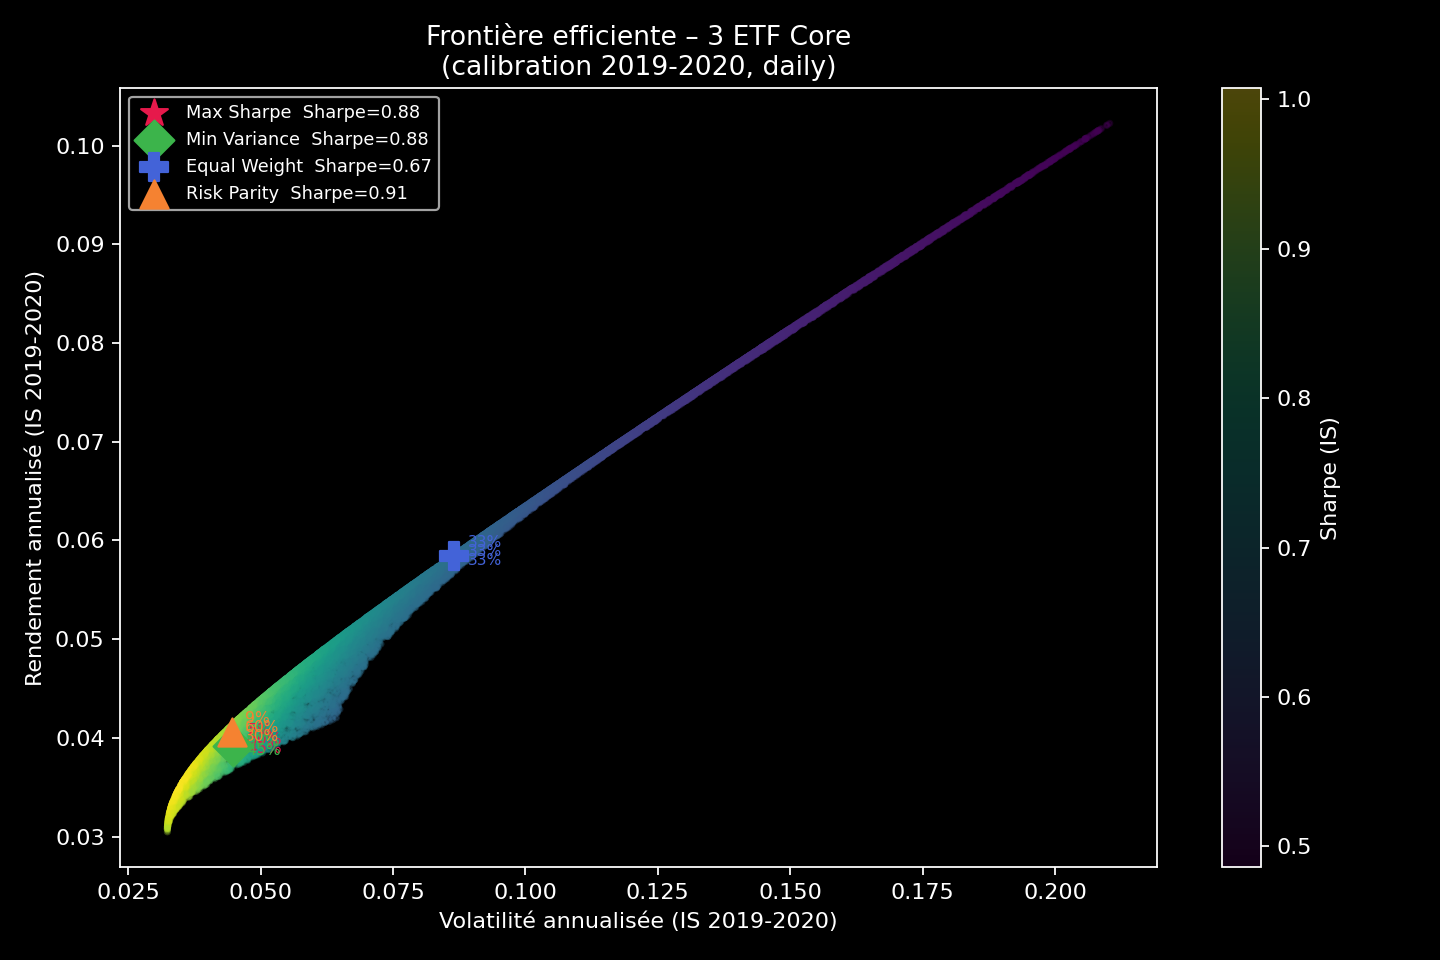

Performance cumulée OOS


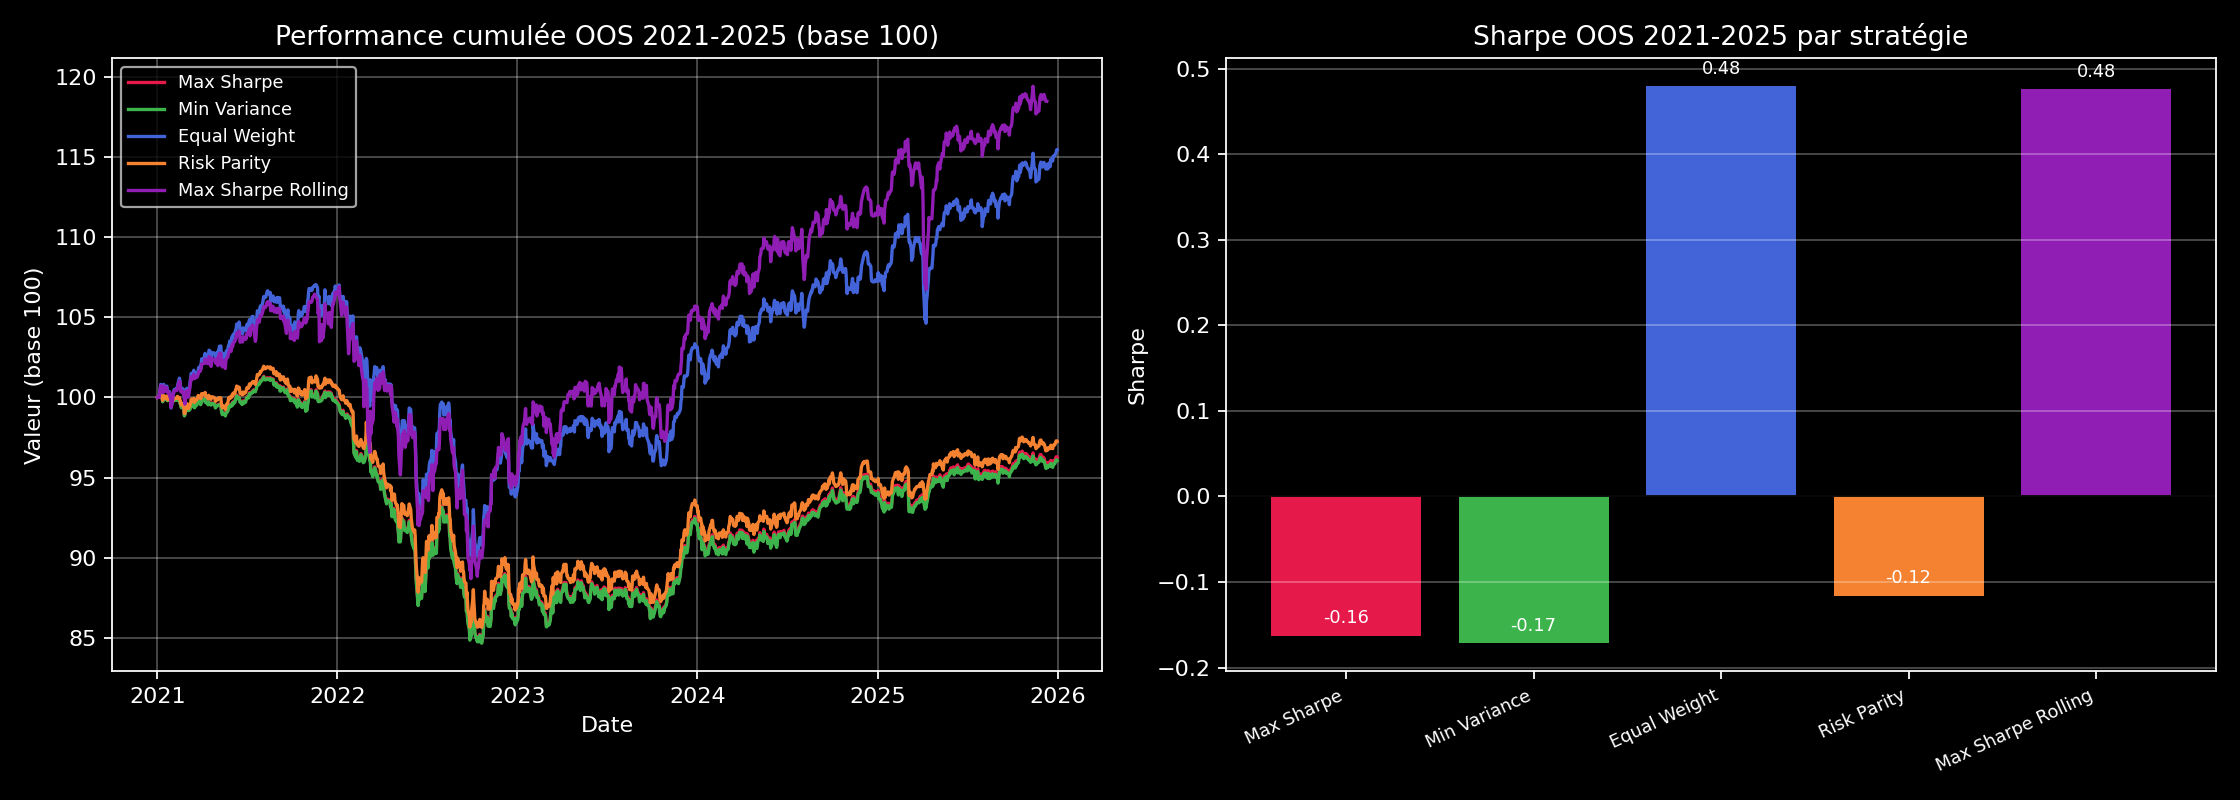

In [6]:
for fig, title in [
    ('outputs/figures/06_efficient_frontier_core.png', 'Frontière efficiente IS'),
    ('outputs/figures/07_core_strategies_oos_perf.png', 'Performance cumulée OOS'),
]:
    if Path(fig).exists():
        print(title)
        display(Image(fig))

---
## Étape 3 — Sélection des fonds Satellite

**19 fonds** pré-sélectionnés en 3 blocs, chargement centralisé STRAT1+2+3.  
Filtres : Beta initial, AUM/Devise, Vol/Frais, Sharpe/Alpha/Corr, Skew/Kurt, Pairwise.

In [7]:
import os
os.environ['SAT_ALLOWED_CURRENCIES'] = 'Euro'

from src.satellite_pipeline import main as sat_main
sat_main()

  PIPELINE SATELLITE v3 – Shortlist + Filtres IS renforcés
  Fenêtre calib : 2019-01-01 → 2020-12-31
  Filtre devise : ['Euro']
  Shortlist : 19 fonds pré-sélectionnés

[0] Chargement des données (STRAT1 + STRAT2 + STRAT3)...
    Lecture prix : STRAT1_price.xlsx
    Lecture prix : STRAT2_price.xlsx
    Lecture prix : STRAT3_price.xlsx
    → 870 tickers prix chargés au total
    Lecture info : STRAT1_info.xlsx
    Lecture info : STRAT2_info.xlsx
    Lecture info : STRAT3_info.xlsx
    → 888 tickers info chargés au total

[1] Chargement des rendements Core...
    1289 obs. daily | 2021-01-01 → 2025-12-10
    Benchmark filtre beta : Core équipondéré (3 ETF sélectionnés via CSV)
    2198 obs. daily | 2017-09-27 → 2026-02-27

  Bloc 1 – Décorrélation / Convexité
  [données] 870 fonds avec prix ET info (tous fichiers confondus)
  [shortlist] 2 fonds retenus sur 2 de la shortlist
  [métriques] Calcul sur calib 2019-01-01 → 2020-12-31...
  [beta init] Rolling 63j vs Core équipondéré...
  [Niv.

In [8]:
sat_sel = pd.read_csv('outputs/satellite_selected.csv').set_index('ticker')
cols_pref = ['bloc','strategie','devise','aum_usd_m','expense_pct',
    'vol_calib','sharpe_calib','alpha_annual','beta_core','drawdown_calib','n_obs_calib']
cols_show = [c for c in cols_pref if c in sat_sel.columns]
fmt = {'aum_usd_m':'{:,.0f}','expense_pct':'{:.2f}','vol_calib':'{:.2%}',
    'sharpe_calib':'{:.2f}','alpha_annual':'{:.2%}','beta_core':'{:.3f}',
    'drawdown_calib':'{:.2%}','n_obs_calib':'{:.0f}'}
fmt = {k:v for k,v in fmt.items() if k in cols_show}
print(f"✅ {len(sat_sel)} fonds satellite sélectionnés :")
display(sat_sel[cols_show].sort_values('bloc').style.format(fmt) if cols_show else sat_sel)

# V3 enrichie
v3_path = 'outputs/satellite_selected_v3.csv'
if Path(v3_path).exists():
    v3 = pd.read_csv(v3_path).set_index('ticker')
    v3_cols = [c for c in ['bloc','rank','score','strategie','beta_core',
        'corr_core_calib','dd_covid','ret_rel_covid'] if c in v3.columns]
    if v3_cols:
        print("\n📊 Détails enrichis :")
        fmt_v3 = {'score':'{:.3f}','beta_core':'{:.3f}','corr_core_calib':'{:.3f}',
            'dd_covid':'{:.2%}','ret_rel_covid':'{:.2%}'}
        display(v3[v3_cols].sort_values(['bloc','rank']).style.format(
            {k:v for k,v in fmt_v3.items() if k in v3_cols}))

✅ 4 fonds satellite sélectionnés :


,bloc,strategie,devise,aum_usd_m,expense_pct,vol_calib,sharpe_calib,alpha_annual,beta_core,drawdown_calib,n_obs_calib
ticker,,,,,,,,,,,
DWMAEIA ID Equity,Bloc1,CTA/futures gérés,Euro,678,0.59,8.36%,1.11,nan%,nan,-8.19%,356
PDAIEUR LX Equity,Bloc2,Multi-stratégie,Euro,"2,139",1.56,3.86%,1.89,nan%,nan,-3.82%,387
EXCRISA LX Equity,Bloc2,Equity Hedge,Euro,"1,504",1.37,3.48%,2.38,nan%,nan,-3.46%,404
REYLSEB LX Equity,Bloc2,Equity Hedge,Euro,210,2.64,7.76%,0.17,nan%,nan,-7.45%,391



📊 Détails enrichis :


,bloc,rank,score,strategie,beta_core,corr_core_calib,dd_covid,ret_rel_covid
ticker,,,,,,,,
DWMAEIA ID Equity,Bloc1,1,0.000,CTA/futures gérés,nan,nan,-5.38%,nan%
PDAIEUR LX Equity,Bloc2,1,0.153,Multi-stratégie,nan,nan,-3.82%,nan%
EXCRISA LX Equity,Bloc2,2,0.049,Equity Hedge,nan,nan,-3.46%,nan%
REYLSEB LX Equity,Bloc2,3,-0.202,Equity Hedge,nan,nan,-7.45%,nan%


---
## Étape 4 — Construction et backtest du fonds Core-Satellite

- **Core 70-75%** (Max-Sharpe Rolling) + **Satellite 25-30%** (equal-weight 1/n)
- Calibration IS 2019-2020, backtest OOS 2021-2025
- TER Core lu depuis `univers_core_etf_eur_daily_wide.xlsx` (onglets Equity/Rates/Credit)

In [9]:
from src.fond_construction import main as fond_main
fond_main()

  CONSTRUCTION DU FONDS CORE-SATELLITE
  Calibration : 2019-01-01 → 2020-12-31
  Backtest    : 2021-01-01 → 2025-12-31

[1] Chargement des données...
  ⚠  Frais Core: 3/3 ETF sans TER metadata, fallback 25 bps.
  Frais Core estimés (data-driven): 25.0 bps/an
    Core  : 1812 obs. | 2019-01-01 → 2025-12-10
    Satellite : 4 fonds | 1970-01-01 → 2025-12-31
    Couverture par période :
      DWMAEIA ID Equity               calib=473 obs  oos=1166 obs  ✓
      PDAIEUR LX Equity               calib=501 obs  oos=1251 obs  ✓
      EXCRISA LX Equity               calib=512 obs  oos=1281 obs  ✓
      REYLSEB LX Equity               calib=504 obs  oos=1256 obs  ✓

  Blocs (2) : {'Bloc1': 1, 'Bloc2': 3}

[2] Allocation equal-weight des poids satellite...
  Fonds retenus : 4 / 4
  Poids par fonds (equal-weight) : 25.0%

  Poids satellite (equal-weight 1/n) :
    DWMAEIA ID Equity                25.0%   [Bloc1 – CTA/futures gérés]
    PDAIEUR LX Equity                25.0%   [Bloc2 – Multi-stratégi

In [10]:
if Path('outputs/fond_metrics.csv').exists():
    metrics = pd.read_csv('outputs/fond_metrics.csv', index_col=0)
    print('Métriques du fonds Core-Satellite (OOS 2021-2025) :')
    display(metrics.style.format('{:.4f}'))
else:
    print("⚠ fond_metrics.csv non trouvé.")

Métriques du fonds Core-Satellite (OOS 2021-2025) :


,valeur
vol_portfolio_ann,0.0539
ret_ann_portfolio,0.0354
sharpe_portfolio,0.6570
max_drawdown,-0.1212
alpha_portfolio_ann,0.0112
beta_portfolio,0.7524
vol_core_ann,0.0708
ret_ann_core,0.0314
sharpe_core,0.4433
vol_satellite_ann,0.0323


In [11]:
if Path('outputs/fond_weights.csv').exists():
    w_df = pd.read_csv('outputs/fond_weights.csv', index_col=0)
    print('Poids satellite :')
    styler = w_df.style.format('{:.4f}')
    for c, color in [('theta_satellite','#3cb44b'), ('w_sat','#4363d8')]:
        if c in w_df.columns:
            styler = styler.bar(subset=[c], color=color)
    display(styler)

Poids satellite :


,theta_satellite,absolute_weight,w_core,w_sat,portfolio_scale
DWMAEIA ID Equity,0.2500,0.0625,0.7500,0.2500,1.0000
PDAIEUR LX Equity,0.2500,0.0625,0.7500,0.2500,1.0000
EXCRISA LX Equity,0.2500,0.0625,0.7500,0.2500,1.0000
REYLSEB LX Equity,0.2500,0.0625,0.7500,0.2500,1.0000


In [12]:
if Path('outputs/fond_annual_perf.csv').exists():
    ann = pd.read_csv('outputs/fond_annual_perf.csv', index_col=0)
    ann.index = ann.index.astype(int)
    print('Performance annuelle :')
    display(ann.style.format('{:.2%}')
        .map(lambda v: 'color: green' if v > 0 else 'color: red')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightyellow'))

Performance annuelle :


,portfolio,core,satellite
2021,5.65%,6.27%,3.78%
2022,-7.59%,-11.51%,4.44%
2023,8.28%,11.48%,-0.89%
2024,6.70%,5.31%,11.07%
2025,5.92%,6.08%,5.45%


---
## Étape 4bis — Analyse de décorrélation et justification Core-Satellite

Cette section analyse quantitativement **l'apport de la poche satellite** au portefeuille :
1. **Corrélation & Beta** : chaque satellite vs Core (OOS 2021-2025)
2. **Bénéfice de diversification** : Sharpe, Vol, MaxDD en fonction de w_sat
3. **Comportement en crises** : COVID 2020, Choc taux 2022, SVB/CS 2023
4. **Stabilité** : rolling correlation 63j
5. **Décomposition Sharpe** : contribution marginale de chaque fonds

In [23]:
# ══════════════════════════════════════════════════════════════════
#  ANALYSE DE DÉCORRÉLATION – JUSTIFICATION CORE-SATELLITE
# ══════════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use('Agg')

from src.satellite_pipeline import lire_prix_wide
from scipy import stats

print("=" * 65)
print("  ANALYSE DE DÉCORRÉLATION – JUSTIFICATION CORE-SATELLITE")
print("=" * 65)

# ── Chargement Core ──
from src.core_pipeline import _lire_wide_values
core_excel = str(Path.cwd() /"univers_core_etf_eur_daily_wide_VF.xlsx")
core_sel = pd.read_csv("outputs/core_selected_etfs.csv")
core_tickers = core_sel["core_etfs"].tolist()

core_prices_dict = {}
for sheet in ['Equity_Wide_Daily_Values', 'Rates_Wide_Daily_Values', 'Credit_Wide_Daily_Values']:
    w = _lire_wide_values(core_excel, sheet)
    for t in core_tickers:
        if t in w.columns and t not in core_prices_dict:
            core_prices_dict[t] = w[t]

core_prices = pd.DataFrame(core_prices_dict).dropna()
core_idx = (core_prices / core_prices.iloc[0]).mean(axis=1)
core_rets = core_idx.pct_change().dropna()
core_rets.name = 'Core'

# ── Chargement Satellite ──
sat_info = pd.read_csv("outputs/satellite_selected.csv")
sat_tickers = sat_info["ticker"].tolist()

sat_prices_frames = []
for p in [str(Path.cwd() / "data" / f"STRAT{i}_price.xlsx") for i in [1,2,3]]:
    if Path(p).exists():
        w = lire_prix_wide(p)
        cols = [t for t in sat_tickers if t in w.columns]
        if cols:
            sat_prices_frames.append(w[cols])
sat_prices = pd.concat(sat_prices_frames, axis=1).sort_index()
sat_prices = sat_prices.loc[:, ~sat_prices.columns.duplicated(keep='first')]

sat_rets = sat_prices.ffill().pct_change()
sat_pocket = sat_rets[sat_tickers].dropna(how='all').mean(axis=1)
sat_pocket.name = 'Satellite'

# ── Alignement OOS ──
aligned = pd.concat([core_rets, sat_pocket], axis=1, sort=True).dropna()
oos = aligned.loc['2021':'2025']
print(f"  OOS : {oos.index.min().date()} → {oos.index.max().date()} ({len(oos)} obs)")

  ANALYSE DE DÉCORRÉLATION – JUSTIFICATION CORE-SATELLITE
  OOS : 2021-01-01 → 2025-12-31 (1304 obs)


In [16]:
# ── 1. CORRÉLATION & BETA PAR FONDS ──
print("\n─── 1. Corrélation & Beta satellite vs Core (OOS 2021-2025) ───\n")

rows_corr = []
for _, row in sat_info.iterrows():
    t = row['ticker']
    bloc = row.get('bloc', '?')
    strat = row.get('strategie', '?')
    if t not in sat_rets.columns:
        continue
    s = sat_rets[t]
    a = pd.concat([s.rename('fund'), core_rets], axis=1, sort=True).dropna()
    a = a.loc['2021':'2025']
    if len(a) < 100:
        continue
    corr = float(a['fund'].corr(a['Core']))
    slope, intercept, _, pval, _ = stats.linregress(a['Core'].values, a['fund'].values)
    rows_corr.append({
        'Fonds': t.split()[0],
        'Bloc': bloc,
        'Stratégie': str(strat)[:25],
        'ρ (Core)': corr,
        'β': slope,
        'α ann.': intercept * 252,
        'p-val β': pval,
    })

# Ajouter la poche agrégée
slope_p, intercept_p, _, pval_p, _ = stats.linregress(oos['Core'].values, oos['Satellite'].values)
rows_corr.append({
    'Fonds': 'POCHE SAT (EW)',
    'Bloc': '—',
    'Stratégie': 'Equal-weight',
    'ρ (Core)': float(oos['Core'].corr(oos['Satellite'])),
    'β': slope_p,
    'α ann.': intercept_p * 252,
    'p-val β': pval_p,
})

df_corr = pd.DataFrame(rows_corr).set_index('Fonds')
display(df_corr.style.format({
    'ρ (Core)': '{:+.3f}', 'β': '{:+.3f}', 'α ann.': '{:+.2%}', 'p-val β': '{:.4f}'
}).background_gradient(subset=['ρ (Core)'], cmap='RdYlGn_r', vmin=-0.3, vmax=0.3)
 .background_gradient(subset=['α ann.'], cmap='RdYlGn', vmin=-0.05, vmax=0.10))


─── 1. Corrélation & Beta satellite vs Core (OOS 2021-2025) ───



,Bloc,Stratégie,ρ (Core),β,α ann.,p-val β
Fonds,,,,,,
DWMAEIA,Bloc1,CTA/futures gérés,+0.046,+0.065,+5.76%,0.0951
PDAIEUR,Bloc2,Multi-stratégie,+0.094,+0.044,+2.46%,0.0006
EXCRISA,Bloc2,Equity Hedge,+0.261,+0.120,+2.38%,0.0000
REYLSEB,Bloc2,Equity Hedge,-0.148,-0.137,+7.78%,0.0000
POCHE SAT (EW),—,Equal-weight,+0.048,+0.023,+4.60%,0.0850


In [17]:
# ── 2. BÉNÉFICE DE DIVERSIFICATION ──
print("\n─── 2. Sharpe / Vol / MaxDD en fonction du poids satellite (OOS) ───\n")

rows_div = []
for w_sat in [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    port = (1 - w_sat) * oos['Core'] + w_sat * oos['Satellite']
    vol = float(port.std() * np.sqrt(252))
    ret_ann = float((1 + port).prod() ** (252 / len(port)) - 1)
    sharpe = ret_ann / vol if vol > 0 else np.nan
    cum = (1 + port).cumprod()
    dd = float(((cum / cum.cummax()) - 1).min())
    rows_div.append({
        'w_sat': f"{w_sat:.0%}",
        'Ret ann.': ret_ann,
        'Vol ann.': vol,
        'Sharpe': sharpe,
        'Max DD': dd,
        'Δ Sharpe vs 0%': sharpe - rows_div[0]['Sharpe'] if rows_div else 0,
    })
if rows_div:
    rows_div[0]['Δ Sharpe vs 0%'] = 0.0

df_div = pd.DataFrame(rows_div).set_index('w_sat')
display(df_div.style.format({
    'Ret ann.': '{:+.2%}', 'Vol ann.': '{:.2%}', 'Sharpe': '{:.2f}',
    'Max DD': '{:.2%}', 'Δ Sharpe vs 0%': '{:+.3f}'
}).background_gradient(subset=['Sharpe'], cmap='RdYlGn')
 .background_gradient(subset=['Max DD'], cmap='RdYlGn'))

# ── Figure : Sharpe vs w_sat ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ww = [0, 5, 10, 15, 20, 25, 30]
sh = df_div['Sharpe'].values
dd = df_div['Max DD'].values * 100

ax1.plot(ww, sh, 'o-', color='#4363d8', lw=2, markersize=8)
ax1.fill_between(ww, sh, alpha=0.1, color='#4363d8')
ax1.set_xlabel('Poids Satellite (%)')
ax1.set_ylabel('Sharpe OOS')
ax1.set_title('Sharpe vs allocation satellite')
ax1.axvline(25, color='orange', ls='--', lw=1, label='w_sat = 25%')
ax1.legend()

ax2.plot(ww, dd, 'o-', color='#e6194b', lw=2, markersize=8)
ax2.fill_between(ww, dd, alpha=0.1, color='#e6194b')
ax2.set_xlabel('Poids Satellite (%)')
ax2.set_ylabel('Max Drawdown OOS (%)')
ax2.set_title('Max Drawdown vs allocation satellite')
ax2.axvline(25, color='orange', ls='--', lw=1, label='w_sat = 25%')
ax2.legend()

fig_dir = Path('outputs/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(fig_dir / 'E01_diversification_benefit.png', dpi=150, bbox_inches='tight')
plt.close('all')
print(f"  -> {fig_dir / 'E01_diversification_benefit.png'}")


─── 2. Sharpe / Vol / MaxDD en fonction du poids satellite (OOS) ───



,Ret ann.,Vol ann.,Sharpe,Max DD,Δ Sharpe vs 0%
w_sat,,,,,
0%,+3.61%,6.67%,0.54,-16.38%,+0.000
5%,+3.68%,6.35%,0.58,-15.42%,+0.039
10%,+3.75%,6.03%,0.62,-14.46%,+0.080
15%,+3.82%,5.71%,0.67,-13.49%,+0.126
20%,+3.88%,5.41%,0.72,-12.53%,+0.176
25%,+3.94%,5.11%,0.77,-11.56%,+0.231
30%,+4.01%,4.81%,0.83,-10.59%,+0.291


  -> outputs\figures\E01_diversification_benefit.png


In [24]:
# ── 3. COMPORTEMENT EN CRISES ──
print("\n─── 3. Comportement en période de stress ───\n")

crises = [
    ('COVID fév-mars 2020', '2020-02-15', '2020-03-31'),
    ('Choc taux 2022',      '2022-01-01', '2022-10-31'),
    ('SVB/CS mars 2023',    '2023-03-01', '2023-03-31'),
]

rows_crisis = []
for crisis, start, end in crises:
    c = core_rets.loc[start:end].dropna()
    s = sat_pocket.loc[start:end].dropna()
    if len(c) < 3 or len(s) < 3:
        continue
    a = pd.concat([c, s], axis=1, sort=True).dropna()
    ret_c = float((1 + a['Core']).prod() - 1)
    ret_s = float((1 + a['Satellite']).prod() - 1)
    
    row = {'Crise': crisis, 'Core': ret_c, 'Satellite': ret_s, 'Spread': ret_s - ret_c}
    
    # Per fund
    for _, info_row in sat_info.iterrows():
        t = info_row['ticker']
        if t in sat_rets.columns:
            fs = sat_rets[t].loc[start:end].dropna()
            if len(fs) > 3:
                row[t.split()[0]] = float((1 + fs).prod() - 1)
    rows_crisis.append(row)

df_crisis = pd.DataFrame(rows_crisis).set_index('Crise')
fmt_crisis = {c: '{:+.2%}' for c in df_crisis.columns}
display(df_crisis.style.format(fmt_crisis)
    .background_gradient(cmap='RdYlGn', axis=None, vmin=-0.15, vmax=0.15))


─── 3. Comportement en période de stress ───



,Core,Satellite,Spread,DWMAEIA,PDAIEUR,EXCRISA,REYLSEB
Crise,,,,,,,
COVID fév-mars 2020,-11.75%,-3.33%,+8.41%,-3.44%,-0.99%,-0.32%,-8.56%
Choc taux 2022,-13.33%,+4.72%,+18.05%,+27.24%,-7.27%,+1.72%,-0.30%
SVB/CS mars 2023,+1.08%,-2.17%,-3.25%,-6.80%,+1.19%,-1.68%,-1.36%


In [25]:
# ── 4. STABILITÉ DE LA DÉCORRÉLATION ──
print("\n─── 4. Corrélation rolling 63j Core vs Satellite (OOS) ───\n")

roll_corr = oos['Core'].rolling(63).corr(oos['Satellite']).dropna()

print(f"  Moyenne : {roll_corr.mean():.3f}")
print(f"  Médiane : {roll_corr.median():.3f}")
print(f"  [Min, Max] : [{roll_corr.min():.3f}, {roll_corr.max():.3f}]")
print(f"  % temps |ρ| ≤ 0.20 : {(roll_corr.abs() <= 0.20).mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 4.5))
roll_corr.plot(ax=ax, color='#4363d8', lw=1.5)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(0.20, color='orange', lw=1, ls=':', label='±0.20')
ax.axhline(-0.20, color='orange', lw=1, ls=':')
ax.fill_between(roll_corr.index, -0.20, 0.20, alpha=0.07, color='green', label='Zone décorrélée')
ax.fill_between(roll_corr.index, roll_corr, 0, alpha=0.15, color='#4363d8')
ax.set_title('Corrélation rolling 63j : Poche Satellite vs Core (OOS 2021-2025)')
ax.set_ylabel('Corrélation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'E02_rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.close('all')
print(f"  -> {fig_dir / 'E02_rolling_correlation.png'}")


─── 4. Corrélation rolling 63j Core vs Satellite (OOS) ───

  Moyenne : 0.095
  Médiane : 0.192
  [Min, Max] : [-0.651, 0.615]
  % temps |ρ| ≤ 0.20 : 28.9%
  -> outputs\figures\E02_rolling_correlation.png


In [26]:
# ── 5. DÉCOMPOSITION SHARPE ──
print("\n─── 5. Amélioration Sharpe : Core seul vs Core+Satellite ───\n")

core_only = oos['Core']
port_25 = 0.75 * oos['Core'] + 0.25 * oos['Satellite']

vol_c = float(core_only.std() * np.sqrt(252))
vol_p = float(port_25.std() * np.sqrt(252))
ret_c = float((1 + core_only).prod() ** (252/len(core_only)) - 1)
ret_p = float((1 + port_25).prod() ** (252/len(port_25)) - 1)
sh_c = ret_c / vol_c
sh_p = ret_p / vol_p

summary = pd.DataFrame({
    'Core seul': {'Ret ann.': f'{ret_c:+.2%}', 'Vol ann.': f'{vol_c:.2%}',
                  'Sharpe': f'{sh_c:.2f}', 'Max DD': f'{float(((1+core_only).cumprod() / (1+core_only).cumprod().cummax() - 1).min()):.2%}'},
    'Core+Sat 75/25': {'Ret ann.': f'{ret_p:+.2%}', 'Vol ann.': f'{vol_p:.2%}',
                       'Sharpe': f'{sh_p:.2f}', 'Max DD': f'{float(((1+port_25).cumprod() / (1+port_25).cumprod().cummax() - 1).min()):.2%}'},
    'Delta': {'Ret ann.': f'{(ret_p-ret_c)*100:+.1f} bps', 'Vol ann.': f'{(vol_p-vol_c)*100:+.1f} bps',
              'Sharpe': f'{sh_p-sh_c:+.3f} ({(sh_p/sh_c-1)*100:+.0f}%)', 'Max DD': f'{((((1+port_25).cumprod() / (1+port_25).cumprod().cummax() - 1).min()) - (((1+core_only).cumprod() / (1+core_only).cumprod().cummax() - 1).min()))*100:+.1f} pts'},
})
display(summary)

print(f"\n  → L'ajout de 25% de satellite améliore le Sharpe de {sh_p-sh_c:+.3f} ({(sh_p/sh_c-1)*100:+.0f}%)")
print(f"    principalement par réduction de la volatilité ({(vol_p-vol_c)*100:+.1f} bps, soit {(vol_p/vol_c-1)*100:+.1f}%)")
print(f"    tout en maintenant un rendement comparable ({(ret_p-ret_c)*100:+.1f} bps)")


─── 5. Amélioration Sharpe : Core seul vs Core+Satellite ───



,Core seul,Core+Sat 75/25,Delta
Ret ann.,+3.61%,+3.94%,+0.3 bps
Vol ann.,6.67%,5.11%,-1.6 bps
Sharpe,0.54,0.77,+0.231 (+43%)
Max DD,-16.38%,-11.56%,+4.8 pts



  → L'ajout de 25% de satellite améliore le Sharpe de +0.231 (+43%)
    principalement par réduction de la volatilité (-1.6 bps, soit -23.5%)
    tout en maintenant un rendement comparable (+0.3 bps)


---
## Étape 6 — Visualisations complètes

In [21]:
from src.plots_report import main as plots_main
plots_main()

  GÉNÉRATION DES GRAPHIQUES – RAPPORT CORE-SATELLITE

[1] Chargement des données...
    Backtest : 2021-01-01 → 2025-12-10 (1289 obs)

[2] Section A – Poche Core (7 figures)...
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\A01_core_etf_cum.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\A02_core_portfolio_cum.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\A03_core_drawdown.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\A04_core_rolling_vol.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\A05_core_rolling_sharpe.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\A06_core_annual_bar.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\A07_core_fees_bar.png

[3] Section B – Poche Satellite (7 figures)...
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\B01_sat_fund_c

C:\Users\Marius\Desktop\M2\Cross Asset Solutions\Projet Fonds\Core_Satellite_Quant\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\D01_portfolio_cum.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\D02_portfolio_drawdown.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\D03_portfolio_annual.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\D04_portfolio_vol_target.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\D05_beta_sat_rolling.png
  -> C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures\D06_portfolio_dist.png

  ✓  28 figures dans C:\Users\Marius\PycharmProjects\Core_Satellite_Quant\outputs\figures


---
## Récapitulatif — Tableau de bord

In [22]:
# ── Comparaison des 5 stratégies Core ──
if Path('outputs/core_portfolio_comparison.csv').exists():
    comp = pd.read_csv('outputs/core_portfolio_comparison.csv', index_col=0)
    rename = {'IS_ret_ann':'Rdt IS','IS_vol_ann':'Vol IS','IS_sharpe':'Sharpe IS',
        'OOS_ret_ann':'Rdt OOS','OOS_vol_ann':'Vol OOS','OOS_sharpe':'Sharpe OOS','OOS_mdd':'MDD OOS'}
    comp = comp.rename(columns=rename)
    pct_cols = [c for c in comp.columns if c not in ['Sharpe IS','Sharpe OOS','poids']]
    fmt = {c: '{:.1%}' for c in pct_cols}
    fmt.update({'Sharpe IS': '{:.2f}', 'Sharpe OOS': '{:.2f}'})
    print('=== Comparaison des 5 stratégies Core ===')
    display(comp.drop(columns=['poids'], errors='ignore').style.format(fmt)
        .highlight_max(subset=['Rdt OOS','Sharpe OOS'], color='lightgreen')
        .highlight_min(subset=['MDD OOS','Vol OOS'], color='lightblue'))

# ── Tableau de bord Core-Satellite ──
if Path('outputs/fond_metrics.csv').exists():
    m = pd.read_csv('outputs/fond_metrics.csv', index_col=0)
    mc = m.columns[0]
    def _g(key, pct=True):
        return f"{m.loc[key,mc]:.2%}" if (key in m.index and pct) else (f"{m.loc[key,mc]:.3f}" if key in m.index else '—')

    perf_df = pd.DataFrame({
        'Total': {'Rdt ann.':_g('ret_ann_portfolio'),'Vol ann.':_g('vol_portfolio_ann'),
            'Sharpe':_g('sharpe_portfolio',False),'Max DD':_g('max_drawdown')},
        'Core': {'Rdt ann.':_g('ret_ann_core'),'Vol ann.':_g('vol_core_ann'),
            'Sharpe':_g('sharpe_core',False),'Max DD':'—'},
        'Satellite': {'Rdt ann.':_g('ret_ann_satellite'),'Vol ann.':_g('vol_satellite_ann'),
            'Sharpe':'—','Max DD':'—'},
    })
    print('\n=== TABLEAU DE BORD (OOS 2021-2025) ===')
    display(perf_df)

    print('\n── Alpha / Beta ──')
    display(pd.DataFrame({'Alpha ann.':_g('alpha_portfolio_ann'),'Beta':_g('beta_portfolio',False)},index=['Portfolio']).T)

    print('\n── Satellite décorrélation ──')
    sat_m = {}
    for key,label,pct in [('alpha_satellite_ann','Alpha sat.',True),('beta_satellite_static','Beta stat.',False),
        ('beta_sat_rolling_mean','Beta roll. moy.',False),('corr_core_satellite','ρ(Core,Sat)',False)]:
        sat_m[label] = _g(key,pct)
    display(pd.DataFrame(sat_m,index=['Sat']).T)

    print('\n── Allocation & Frais ──')
    af = {'w_core':_g('w_core'),'w_sat':_g('w_sat')}
    for key,label in [('fees_core_contrib_bps','Frais Core'),('fees_sat_contrib_bps','Frais Sat.'),('fees_total_bps','Total frais')]:
        af[label] = f"{m.loc[key,mc]:.1f} bps" if key in m.index else '—'
    if 'fees_ok' in m.index:
        af['Budget ≤ 80 bps'] = '✓' if m.loc['fees_ok',mc] else '✗'
    display(pd.DataFrame(af,index=['Val']).T)

=== Comparaison des 5 stratégies Core ===


,Rdt IS,Vol IS,Sharpe IS,Rdt OOS,Vol OOS,Sharpe OOS,MDD OOS
strategie,,,,,,,
Max Sharpe,3.9%,4.5%,0.88,-0.7%,4.5%,-0.16,-16.4%
Min Variance,3.9%,4.5%,0.88,-0.8%,4.5%,-0.17,-16.4%
Equal Weight,5.8%,8.7%,0.67,2.8%,5.9%,0.48,-15.8%
Risk Parity,4.1%,4.5%,0.91,-0.5%,4.6%,-0.12,-16.0%
Max Sharpe Rolling,7.3%,8.6%,0.85,3.4%,7.1%,0.48,-17.0%



=== TABLEAU DE BORD (OOS 2021-2025) ===


,Total,Core,Satellite
Rdt ann.,3.54%,3.14%,4.59%
Vol ann.,5.39%,7.08%,3.23%
Sharpe,0.657,0.443,—
Max DD,-12.12%,—,—



── Alpha / Beta ──


,Portfolio
Alpha ann.,1.12%
Beta,0.752



── Satellite décorrélation ──


,Sat
Alpha sat.,4.56%
Beta stat.,0.026
Beta roll. moy.,0.077
"ρ(Core,Sat)",0.056



── Allocation & Frais ──


,Val
w_core,75.00%
w_sat,25.00%
Frais Core,18.8 bps
Frais Sat.,38.5 bps
Total frais,57.2 bps
Budget ≤ 80 bps,✓
